In [290]:
import sys

sys.path.append("../src/")

import matplotlib.pyplot as plt
import torch
from microscope import Aberration, Detector
from pdb2mrc import PDB2MRC
from plotting_tools import *
from scattering import Scattering, complex_potential

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Instantiate class

In [324]:
tx = torch.ones(10)
ty = torch.ones(10)
tz = torch.zeros(10)
T = torch.stack([tx,ty], dim=-1)
T.shape

torch.Size([10, 2])

In [326]:
torch.concat([T, tz[..., None]], dim=-1)


tensor([[1., 1., 0.],
        [1., 1., 0.],
        [1., 1., 0.],
        [1., 1., 0.],
        [1., 1., 0.],
        [1., 1., 0.],
        [1., 1., 0.],
        [1., 1., 0.],
        [1., 1., 0.],
        [1., 1., 0.]])

In [152]:
pdb_code = "5mac"
pm = PDB2MRC(pdb_code)

## Download PDB file

In [153]:
pm.fetch_pdb(pdb_folder="../pdb-data/")

../pdb-data/5mac
PDB file saved to: ../pdb-data/5mac.cif


## Compute particle potential

In [154]:
n = 256
dx = 1
pm.build_particle(n=256, dx=dx)

100%|█████████████████████████████████████████████| 7/7 [00:03<00:00,  2.32it/s]


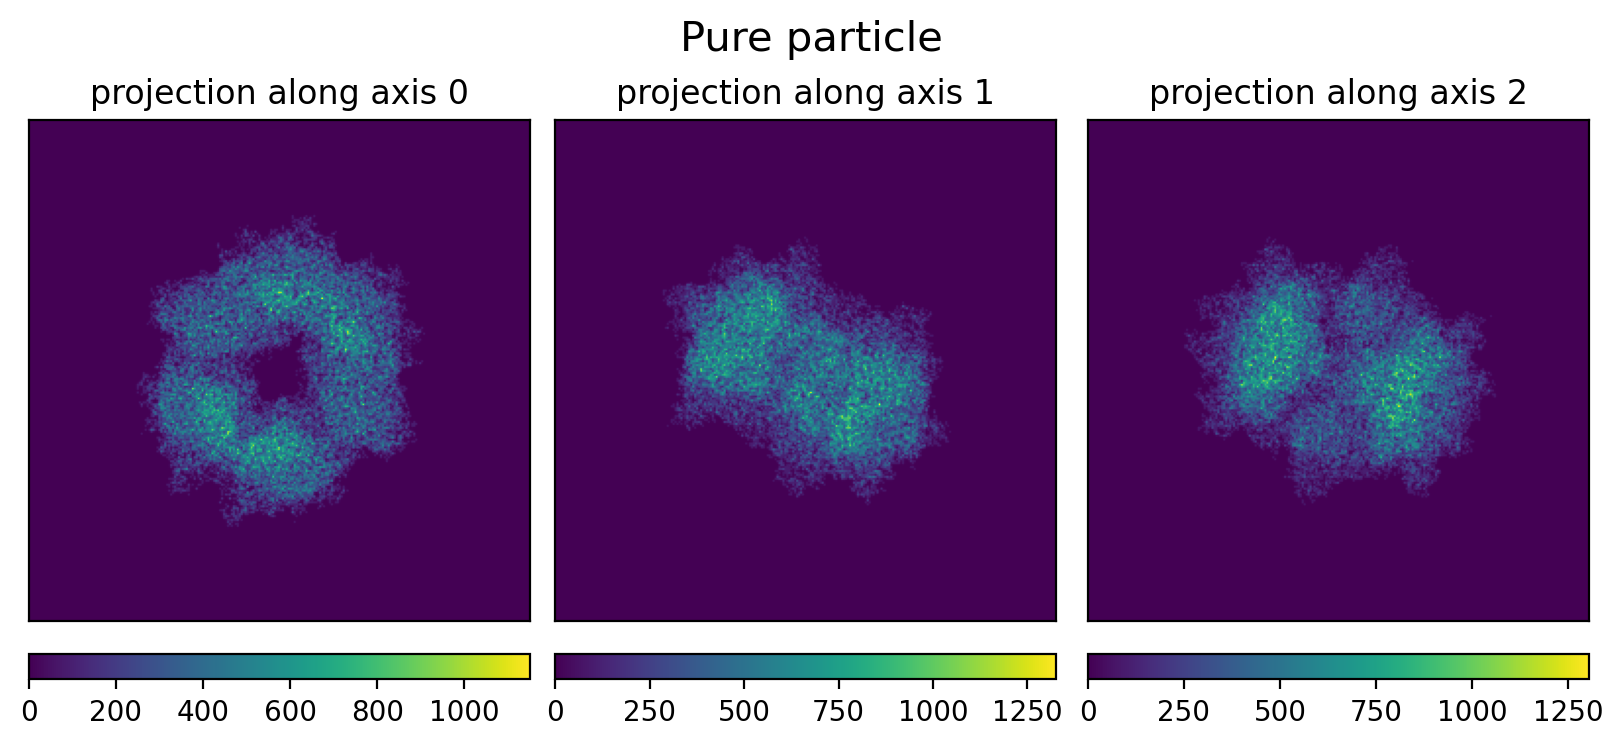

In [155]:
plot3d(pm.particle, title="Pure particle")

## Solvate
Note: Time taken increases exponentially with larger box sizes.
- 256A x 256A x 256A takes 1.5 hours.
- 150A x 150A x 150A takes 3 minutes.
- 100A x 100A x 100A takes 20 seconds.

In [109]:
pm.solvate()

100%|█████████████████████████████████████████████| 5/5 [01:31<00:00, 18.29s/it]


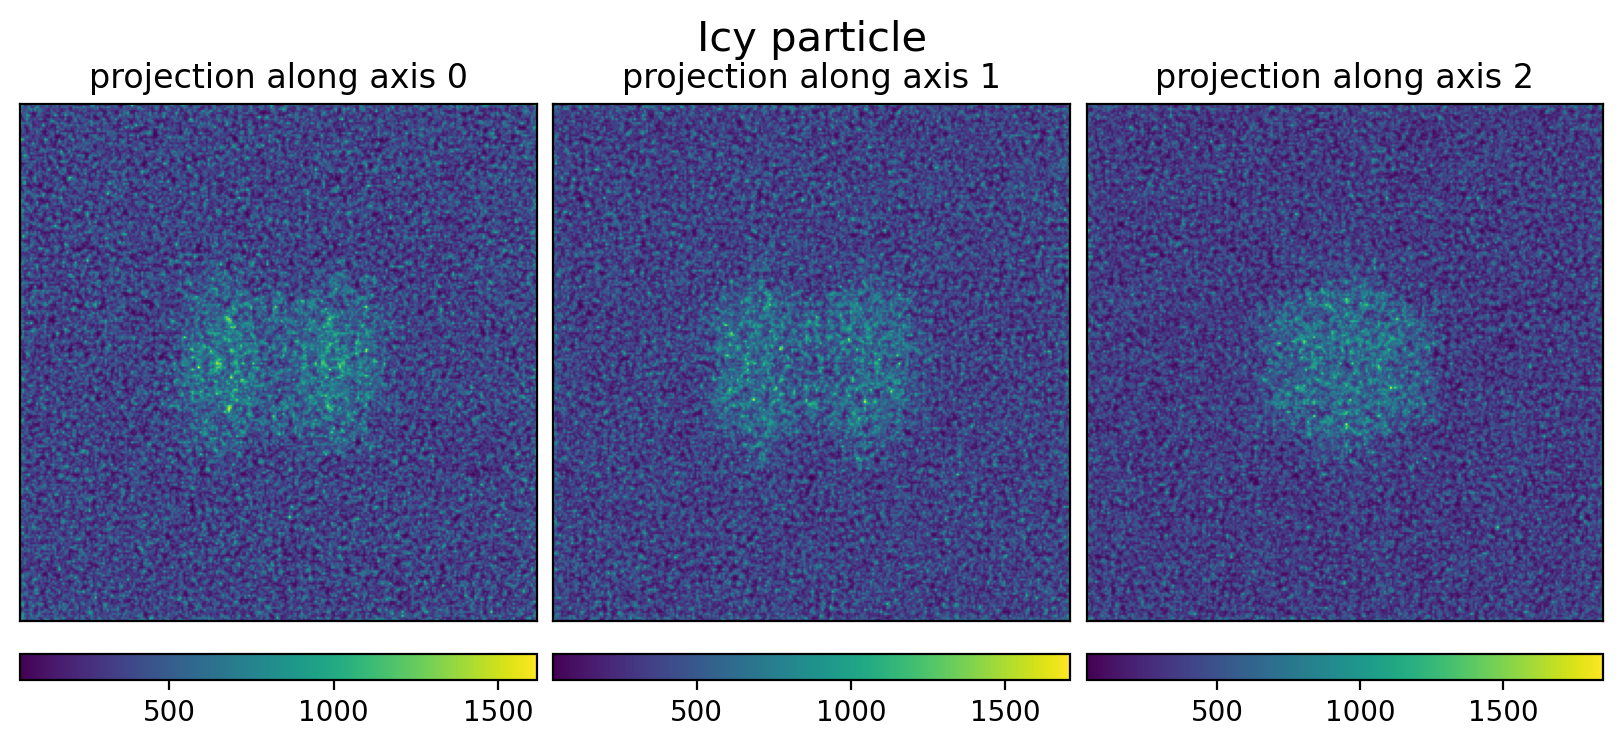

In [110]:
plot3d(pm.icy_particle, title="Icy particle")

## Scattering

In [309]:
energy = 200  # keV
dose_per_angstrom = 20  # e-/A^2
dose_per_pixel = dose_per_angstrom * dx**2  # e-/px^2
scattering_model = "multislice"
aberration_model = "holography"
sc = Scattering(
    n,
    dx,
    energy,
    dose_per_angstrom,
    scattering_model=scattering_model,
)

potential = pm.particle.clone()[None, ...]
potential.shape

exitwave = sc(potential)

ab = Aberration(
    n,
    dx,
    energy,
    aberration_model=aberration_model,
    alpha=0.1,
)

cs = torch.tensor([2.7e7])
dfu = torch.tensor([10000])
dfv = torch.tensor([10000])
dfang = torch.tensor([0])
ab_ew = ab(exitwave, cs, dfu, dfv, dfang)

d = Detector(dx, dose_per_angstrom, aberration_model=aberration_model)

im = d(ab_ew)

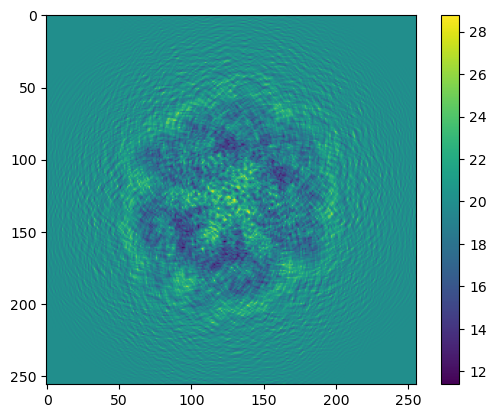

In [308]:
plt.imshow(im[0])
plt.colorbar()

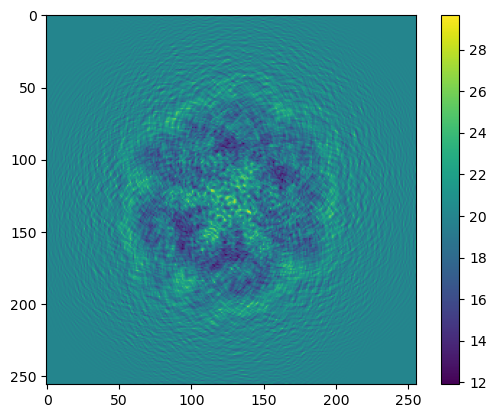

In [310]:
plt.imshow(im[0])
plt.colorbar()

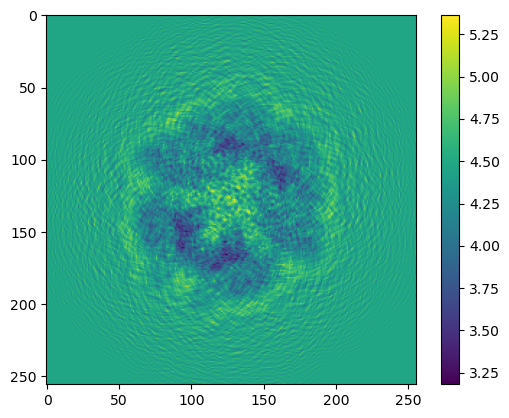

In [255]:
plt.imshow(ab_ew[0].real)
plt.colorbar()

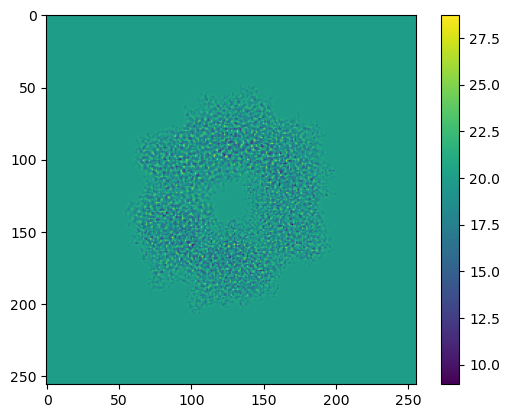

In [170]:
plt.imshow(torch.abs(exitwave[0]) ** 2)
plt.colorbar()

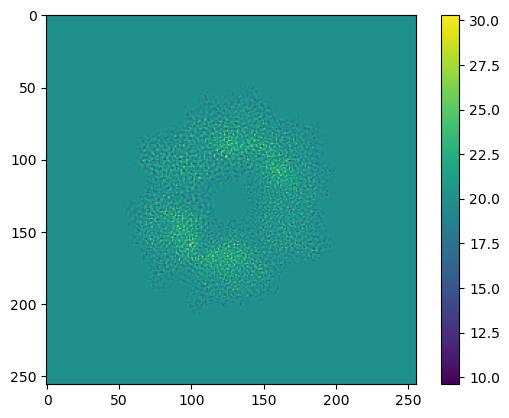

In [175]:
plt.imshow(torch.abs(exitwave[0]) ** 2)
plt.colorbar()